# Notebook 13 – Model Evaluation: Regression
### Sprint 7 – Machine Learning Fundamentals for AI/ML Engineers

**Dataset:** Diabetes dataset — `sklearn.datasets.load_diabetes` (built-in; used for regression per the sprint's
requirement, since Breast Cancer is classification-only). **Target:** disease progression score one year after
baseline.

## Step 1 – Understand the Concept

### MAE – Mean Absolute Error
`MAE = (1/n) Σ |y_actual - y_pred|` — average absolute error size, in target units. Treats all errors linearly.

### MSE – Mean Squared Error
`MSE = (1/n) Σ (y_actual - y_pred)²` — squares errors before averaging, so **large errors are penalized
disproportionately**. Units are squared, hard to interpret directly.

### RMSE – Root Mean Squared Error
`RMSE = sqrt(MSE)` — brings units back to the target's scale while keeping sensitivity to large errors. RMSE ≥
MAE always; a larger gap means a few large outliers dominate.

### R² Score
`R² = 1 - (SS_residual / SS_total)` — proportion of target variance explained, relative to predicting the mean.
R²=1 perfect; R²=0 no better than the mean; can go negative if worse than that baseline.

### Adjusted R²
`Adjusted R² = 1 - [(1-R²)(n-1) / (n-p-1)]`, p = number of predictors. Plain R² always increases (or stays same)
as features are added, even irrelevant ones — Adjusted R² penalizes unnecessary predictors.

### Residual Analysis
Residual = `y_actual - y_pred`. Random scatter around zero = well-specified model. Curved pattern = missing
non-linear structure. Funnel shape = heteroscedasticity (non-uniform error variance).

### When to use each metric
- **MAE:** equal error weighting, interpretability in target units.
- **MSE/RMSE:** large errors especially costly.
- **R²/Adjusted R²:** scale-free summary, comparing models fairly as features are added.

### Advantages / Limitations
| Metric | Advantage | Limitation |
|---|---|---|
| MAE | Robust to outliers, easy to interpret | Doesn't penalize large errors extra |
| MSE | Penalizes large errors, differentiable | Hard to interpret (squared units), sensitive to outliers |
| RMSE | Same scale as target | Still sensitive to outliers |
| R² | Scale-free, intuitive | Always increases with more features |
| Adjusted R² | Penalizes unnecessary complexity | Still assumes linear-model-style variance decomposition |

## Step 2 – Demonstrate the Concept

**Simple example:** A house-price model off by $10k on nine houses and $200k on one: MAE treats the outlier the
same per-dollar; MSE/RMSE spike heavily — very different stories about the same model.

**Real-world example:** Weather forecasting uses RMSE — a wildly wrong forecast is far more damaging than being
off by 1°C ten times.

**Business example:** Retail demand forecasting — MAE reported to managers (interpretable), RMSE monitored
internally to catch rare large failures.

**AI/ML use case:** Comparing regression models with MAE/RMSE/R² together, since no single metric tells the
complete story.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42

data = load_diabetes()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="disease_progression")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("X shape:", X.shape, " y range:", y.min(), "-", y.max())

X shape: (442, 10)  y range: 25.0 - 346.0


## Step 3 – Implement the Concept

In [3]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

n = len(y_test)
p = X_test.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"MAE:         {mae:.2f}")
print(f"MSE:         {mse:.2f}")
print(f"RMSE:        {rmse:.2f}")
print(f"R^2:         {r2:.4f}")
print(f"Adjusted R^2:{adj_r2:.4f}")
print(f"Target mean: {y.mean():.2f}  |  Target std: {y.std():.2f}")

MAE:         42.79
MSE:         2900.19
RMSE:        53.85
R^2:         0.4526
Adjusted R^2:0.3824
Target mean: 152.13  |  Target std: 77.09


### What the code does
`mean_absolute_error`, `mean_squared_error`, `r2_score` are sklearn's built-in implementations. RMSE is derived
manually (`np.sqrt(mse)`). Adjusted R² is computed manually from R², n (test observations), and p (predictors),
since sklearn has no built-in function for it.

### What each metric's output means here
- MAE (42.79) is in the same units as disease progression — predictions are off by ~43 units on average.
- RMSE (53.85) being larger than MAE indicates a few larger errors pull it up.
- R² (0.4526) means the model explains ~45% of the variance in disease progression.

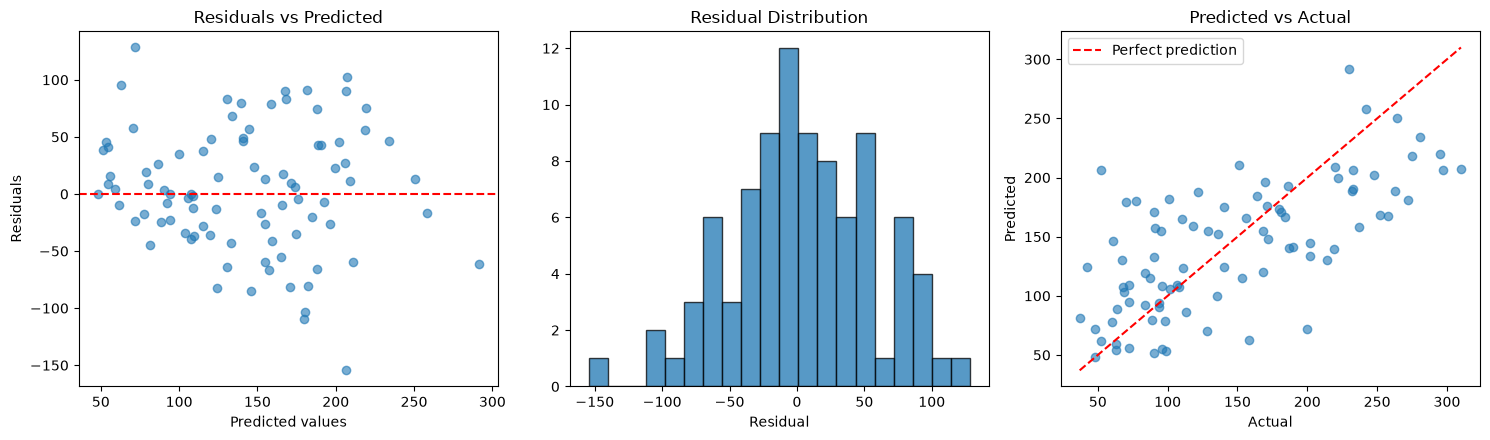

Mean residual: 3.913  (should be close to 0 for an unbiased model)
Residual std: 53.711


In [4]:
# Residual analysis
residuals = y_test.values - y_pred

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].scatter(y_pred, residuals, alpha=0.6)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted values"); axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Predicted")

axes[1].hist(residuals, bins=20, edgecolor="black", alpha=0.75)
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Residual")

axes[2].scatter(y_test, y_pred, alpha=0.6)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[2].plot(lims, lims, color="red", linestyle="--", label="Perfect prediction")
axes[2].set_xlabel("Actual"); axes[2].set_ylabel("Predicted")
axes[2].set_title("Predicted vs Actual")
axes[2].legend()

plt.tight_layout()
plt.show()

print("Mean residual:", round(residuals.mean(), 3), " (should be close to 0 for an unbiased model)")
print("Residual std:", round(residuals.std(), 3))

## Step 4 – Interpret the Result

**Do not simply report R² = 0.45 -- explain it:**
- R² ≈ 0.45 means the model explains ~45% of the variance in disease progression using only baseline clinical
  measurements. **Is that good?** In a medical/biological context influenced by many unmeasured factors
  (genetics, lifestyle, disease biology), this is a reasonable, though not highly precise, baseline — poor for a
  physics-based task, but fairly typical for biomedical regression on limited features.
- **What does MAE add?** It translates error into the target's actual units ("off by ~43 points on average") —
  something a clinician can directly relate to, which R² alone doesn't communicate.
- **What type of errors is the model making?** The residual-vs-predicted plot is the key diagnostic: a mean
  residual near zero (3.913, small relative to the std of 53.7) with no strong funnel/curve pattern supports the
  linear model's assumptions reasonably well.
- **What could be improved?** Feature engineering (interaction/polynomial terms if residuals show curvature),
  trying non-linear models (Random Forest/Gradient Boosting Regressor) and comparing MAE/RMSE/R² side by side, or
  gathering more predictive features.